In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
import numpy as np


In [18]:
file_path = "contratos_limpo.csv"
df = pd.read_csv(file_path, low_memory=False)

### Locais com mais gastos (menos a cat Portugal)

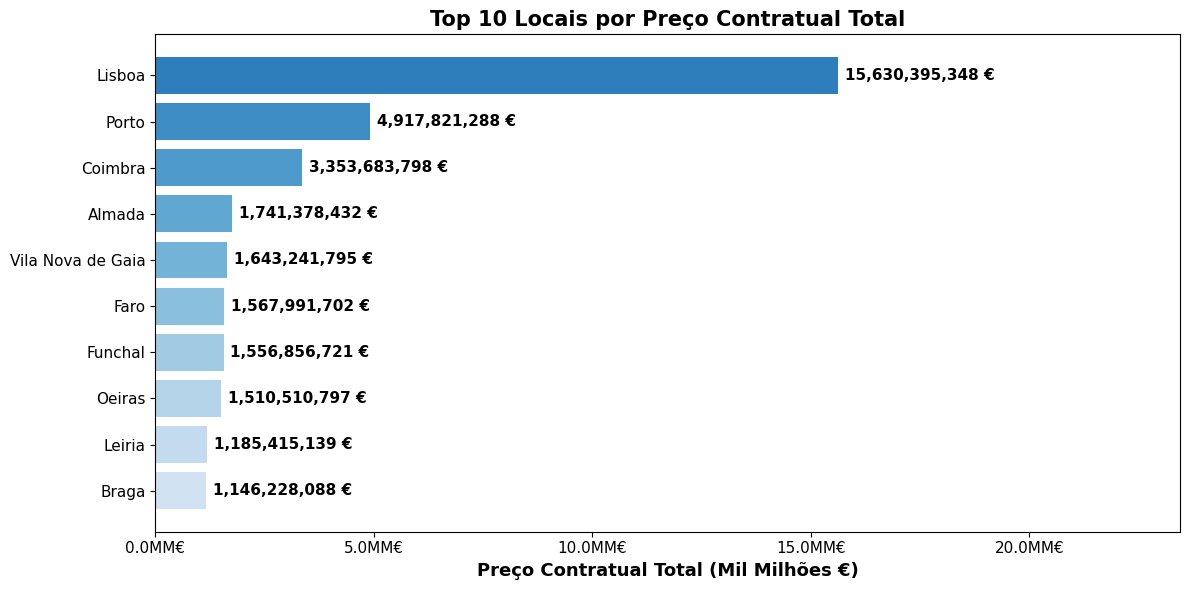

In [19]:
excluir = ["Portugal", "Portugal, Portugal Continental"]

def top10_local_preco(df):
    top10 = (df[~df["LocalExecucao"].isin(excluir)]
               .assign(LocalExecucao_limpo=lambda x: x["LocalExecucao"].str.split(",").str[-1].str.strip())
               .groupby("LocalExecucao_limpo")["precoContratual_2025"]
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())

    fig, ax = plt.subplots(figsize=(12, 6))
    cores = cm.Blues_r(np.linspace(0.3, 0.8, len(top10)))
    bars = ax.barh(top10["LocalExecucao_limpo"], top10["precoContratual_2025"], color=cores)

    ax.invert_yaxis()
    ax.set_xlabel("Preço Contratual Total (Mil Milhões €)", fontsize=13, fontweight="bold")
    ax.set_title("Top 10 Locais por Preço Contratual Total", fontsize=15, fontweight="bold")

    ax.bar_label(
        bars,
        fmt=lambda x: f"{x:,.0f} €",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlim(0, top10["precoContratual_2025"].max() * 1.5)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e9:.1f}MM€"))

    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.show()

    return top10

top10 = top10_local_preco(df)

### Locais com mais contratos

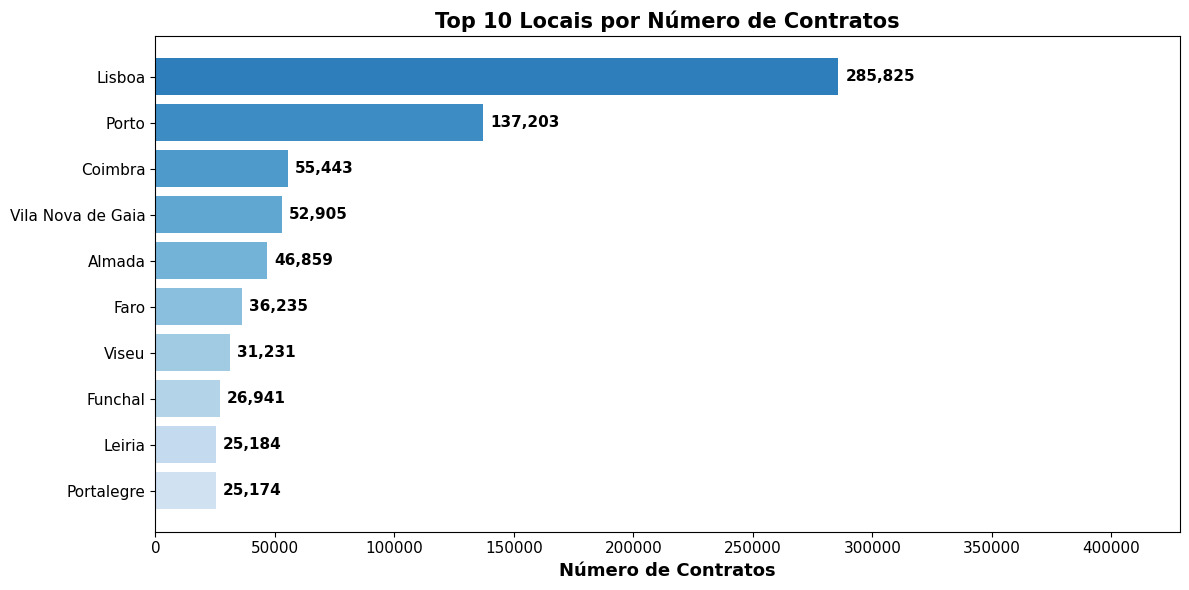

In [20]:
def top10_local_contratos(df):
    top10 = (df[~df["LocalExecucao"].isin(excluir)]
               .assign(LocalExecucao_limpo=lambda x: x["LocalExecucao"].str.split(",").str[-1].str.strip())
               .groupby("LocalExecucao_limpo")["idcontrato"]
               .count()
               .sort_values(ascending=False)
               .head(10)
               .reset_index()
               .rename(columns={"idcontrato": "num_contratos"}))

    fig, ax = plt.subplots(figsize=(12, 6))
    cores = cm.Blues_r(np.linspace(0.3, 0.8, len(top10)))
    bars = ax.barh(top10["LocalExecucao_limpo"], top10["num_contratos"], color=cores)

    ax.invert_yaxis()
    ax.set_xlabel("Número de Contratos", fontsize=13, fontweight="bold")
    ax.set_title("Top 10 Locais por Número de Contratos", fontsize=15, fontweight="bold")

    ax.bar_label(
        bars,
        fmt=lambda x: f"{x:,.0f}",
        padding=5,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlim(0, top10["num_contratos"].max() * 1.5)

    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.show()

    return top10

top10_contratos = top10_local_contratos(df)

### BoxPlot PrazoExecucao

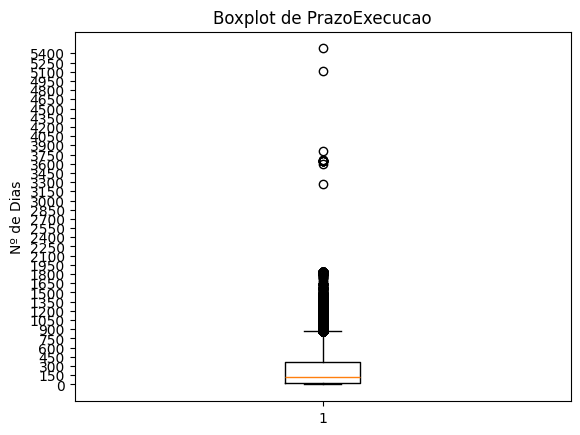

In [21]:
plt.figure()
plt.boxplot(df["prazoExecucao"].dropna())

plt.title("Boxplot de PrazoExecucao")
plt.ylabel("Nº de Dias")

# ticks de 150 em 150
max_val = df["prazoExecucao"].max()
plt.yticks(np.arange(0, max_val, 150))

plt.show()

In [22]:
print(df["prazoExecucao"].quantile([0.25, 0.5, 0.75]))

0.25     28.0
0.50    115.0
0.75    365.0
Name: prazoExecucao, dtype: float64


### Quartis precoContratual

In [23]:
x = pd.to_numeric(df["precoContratual_2025"], errors="coerce")

q0 = x.min()
q1 = x.quantile(0.25)
q2 = x.quantile(0.50)
q3 = x.quantile(0.75)
q4 = x.max()

tabela_intervalos = pd.DataFrame({
    "Quartil": ["Q1", "Q2", "Q3", "Q4"],
    "Intervalo (€)": [
        f"{q0:,.2f} € – {q1:,.2f} €",
        f"{q1:,.2f} € – {q2:,.2f} €",
        f"{q2:,.2f} € – {q3:,.2f} €",
        f"{q3:,.2f} € – {q4:,.2f} €"
    ]
})

tabela_intervalos["Intervalo (€)"] = tabela_intervalos["Intervalo (€)"].str.replace(",", "X").str.replace(".", ",").str.replace("X", ".")

tabela_intervalos

,Quartil,Intervalo (€)
0,Q1,"0,01 € – 3.206,29 €"
1,Q2,"3.206,29 € – 11.541,91 €"
2,Q3,"11.541,91 € – 31.800,00 €"
3,Q4,"31.800,00 € – 77.475.160,00 €"
